# How far can a heat-capacity correlation be trusted?

**CBET Chapter 3 — the ideal-gas heat capacity, and the limits of a tabulated
correlation.** Chapter 6 pays the bill: the error identified here is the largest single
error in Illustration 6.4-1's property table.

$C_P^{*}$ arrives in this chapter as a number you look up and integrate. It is worth
asking, once, how good that number is — because every enthalpy and entropy change in
the rest of the book is an integral of it, and an integral accumulates whatever error
the correlation carries.

Appendix A.II tabulates the ideal-gas heat capacity as a cubic in temperature,

$$C_P^{*}(T) = a + b\,T + c\,T^{2} + d\,T^{3}\qquad[\mathrm{J/(mol\,K)}],\ T\ \text{in K}$$

and — this is the part that is easy to skip — **every row carries a temperature range.**
For oxygen the appendix gives two:

| row | range | *a* | *b*×10² | *c*×10⁵ | *d*×10⁹ |
|---|---|---|---|---|---|
| Low Temperature Range | 273–1800 K | 25.460 | 1.519 | −0.715 | 1.311 |
| Cryogenic Range | 100–700 K | 30.171 | −1.293 | 4.236 | −25.828 |

Two cubics for one gas, overlapping over 273–700 K. That looks like redundancy. It is
not: **each one is accurate only inside its own range, and badly wrong outside it.**
This notebook shows how wrong, and what it costs.

It also *derives* the cryogenic row, so the coefficients above are not something you
have to take on trust — Section 3 reproduces them from the reference data.

> The Chapter 1 exercise `ch1/Heat_capacity_fitting_CHEG231.ipynb` fits this same
> polynomial to CO₂ data as a way of learning `numpy`. Here the fitting is not the
> point — the *range* is.

## 1. The reference data

NIST-JANAF gives $C_P^{*}$ as a **Shomate** equation,

$$C_P^{*} = A + B\,t + C\,t^{2} + D\,t^{3} + \frac{E}{t^{2}},
\qquad t = T/1000$$

and — the first lesson — **NIST itself does not use one set of coefficients.** Oxygen
is split at 700 K, nitrogen at 500 K. If the recognized reference standard needs a
piecewise fit to cover 100–2000 K, no single cubic is going to do it either.

> Chase, M. W., Jr., *NIST-JANAF Thermochemical Tables, Fourth Edition*,
> J. Phys. Chem. Ref. Data Monograph 9 (1998). Retrieved from the NIST Chemistry
> WebBook, `webbook.nist.gov` (O₂ species C7782447, N₂ species C7727379);
> data last reviewed March 1977, parameter fit January 2009.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# NIST-JANAF Shomate coefficients: (T_lo, T_hi, A, B, C, D, E)
SHOMATE = {
    "oxygen":   [(100,  700, 31.32234, -20.23531, 57.86644, -36.50624, -0.007374),
                 (700, 2000, 30.03235,   8.772972, -3.988133,  0.788313, -0.741599)],
    "nitrogen": [(100,  500, 28.98641,   1.853978, -9.647459, 16.63537,  0.000117),
                 (500, 2000, 19.50583,  19.88705,  -8.598535,  1.369784,  0.527601)],
}


def cp_janaf(name, T):
    """Reference Cp*, J/(mol K). Piecewise over the Shomate segments."""
    T = np.atleast_1d(np.asarray(T, float))
    out = np.full(T.shape, np.nan)
    for lo, hi, A, B, C, D, E in SHOMATE[name]:
        m = (T >= lo) & (T <= hi)
        t = T[m] / 1000.0
        out[m] = A + B*t + C*t**2 + D*t**3 + E/t**2
    if np.isnan(out).any():
        raise ValueError("outside the reference's own validity — do not extrapolate it either")
    return out


def cp_poly(c, T):
    """Appendix A.II cubic form."""
    T = np.asarray(T, float)
    return c[0] + c[1]*T + c[2]*T**2 + c[3]*T**3


# The two Appendix A.II rows for oxygen (as printed, unscaled here).
A2_LOW  = {"oxygen":   (25.460,  1.519e-2, -0.715e-5,  1.311e-9),
           "nitrogen": (28.883, -0.157e-2,  0.808e-5, -2.871e-9)}
# As PRINTED in Appendix A.II, at the appendix's own 3-decimal precision -- not the
# full-precision fit. That is the point: a reader who types the printed row into a
# notebook must reproduce the printed tables. Section 3 shows the fit that produced them.
A2_CRYO = {"oxygen":   (30.171, -1.293e-2, 4.236e-5, -2.5828e-8),
           "nitrogen": (29.234, -0.102e-2, 0.025e-5,  6.339e-9)}

print(f"{'T (K)':>7}{'O2 JANAF':>11}{'A.II low':>11}{'A.II cryo':>11}")
for T in (100, 173.15, 273.15, 298.15, 500, 700, 1000, 1800):
    print(f"{T:>7.0f}{cp_janaf('oxygen', T)[0]:>11.3f}"
          f"{cp_poly(A2_LOW['oxygen'], T):>11.3f}"
          f"{cp_poly(A2_CRYO['oxygen'], T):>11.3f}")

  T (K)   O2 JANAF   A.II low  A.II cryo
    100     29.104     26.909     29.276
    173     29.118     27.883     29.068
    273     29.270     29.102     29.273
    298     29.383     29.388     29.397
    500     31.079     31.431     31.067
    700     32.976     33.039     33.017
   1000     34.864     34.811     33.773
   1800     37.271     37.282     -6.485


Look at the last line before going further. At 1800 K the cryogenic row returns a
**negative heat capacity** — a thermodynamic impossibility. Nothing in the algebra
stops you evaluating a polynomial outside the range it was fitted over; only the
range statement in the appendix does.

## 2. Compare over 100–1800 K

Plot both A.II rows against the reference, with each row's stated range shaded, and
the residuals underneath.

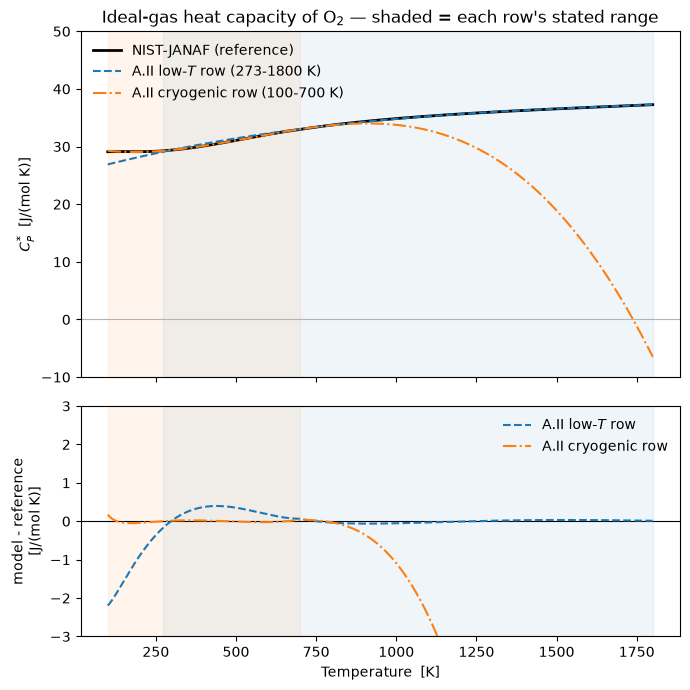

max |error| vs the reference, J/(mol K)        O2
  A.II low-T row   over 100-273 K:    2.195   over 273-700 K:   0.397   over 700-1800 K:     0.063
  A.II cryo row    over 100-273 K:    0.172   over 273-700 K:   0.042   over 700-1800 K:    43.756


In [2]:
T = np.linspace(100, 1800, 1200)
ref = cp_janaf("oxygen", T)
low = cp_poly(A2_LOW["oxygen"], T)
cryo = cp_poly(A2_CRYO["oxygen"], T)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

ax1.axvspan(273, 1800, color="C0", alpha=0.07)
ax1.axvspan(100, 700, color="C1", alpha=0.07)
ax1.plot(T, ref, "k-", lw=2, label="NIST-JANAF (reference)")
ax1.plot(T, low, "C0--", label="A.II low-$T$ row (273-1800 K)")
ax1.plot(T, cryo, "C1-.", label="A.II cryogenic row (100-700 K)")
ax1.axhline(0, color="0.7", lw=0.8)
ax1.set_ylabel(r"$C_P^{*}$  [J/(mol K)]")
ax1.set_title(r"Ideal-gas heat capacity of O$_2$ — shaded = each row's stated range")
ax1.set_ylim(-10, 50)
ax1.legend(frameon=False, loc="upper left")

ax2.axvspan(273, 1800, color="C0", alpha=0.07)
ax2.axvspan(100, 700, color="C1", alpha=0.07)
ax2.axhline(0, color="k", lw=0.8)
ax2.plot(T, low - ref, "C0--", label="A.II low-$T$ row")
ax2.plot(T, cryo - ref, "C1-.", label="A.II cryogenic row")
ax2.set_ylabel("model - reference\n[J/(mol K)]")
ax2.set_xlabel("Temperature  [K]")
ax2.set_ylim(-3, 3)
ax2.legend(frameon=False)
fig.tight_layout()
plt.show()


def worst(c, name, lo, hi):
    Tm = np.linspace(lo, hi, 2000)
    return np.abs(cp_poly(c, Tm) - cp_janaf(name, Tm)).max()


print("max |error| vs the reference, J/(mol K)        O2")
for label, c, in (("A.II low-T row ", A2_LOW["oxygen"]),
                  ("A.II cryo row  ", A2_CRYO["oxygen"])):
    print(f"  {label}  over 100-273 K: {worst(c, 'oxygen', 100, 273):8.3f}"
          f"   over 273-700 K: {worst(c, 'oxygen', 273, 700):7.3f}"
          f"   over 700-1800 K: {worst(c, 'oxygen', 700, 1800):9.3f}")

## 3. Where the cryogenic row comes from

It is the same cubic form, least-squares fitted to the reference over **100–700 K** —
which for oxygen is exactly the span of JANAF's own first Shomate segment, so the fit
never straddles a discontinuity in the reference.

`numpy.polynomial.Polynomial.fit` is numerically better behaved than the older
`polyfit` here, because it fits in a scaled variable and then converts back.

In [3]:
def fit_A2_row(name, lo, hi, n=8000):
    """Least-squares Appendix A.II cubic for `name` over [lo, hi]."""
    Tf = np.linspace(lo, hi, n)
    p = np.polynomial.Polynomial.fit(Tf, cp_janaf(name, Tf), 3).convert()
    return tuple(p.coef)


# Check the fit against the PRINTED row by comparing CURVES, not coefficient tuples.
# Coefficients are the wrong test, and nitrogen shows why: its c is 0.025 x 10^-5, so
# printing it to three decimals throws away 1.6% of it in relative terms, and a
# tuple-wise comparison "fails" on a row that is in fact right. The polynomial is
# ill-conditioned in its coefficients and well-determined in its predictions -- the same
# lesson as ch1/Heat_capacity_fitting_CHEG231.ipynb. Compare what you care about.
for name in ("oxygen", "nitrogen"):
    c = fit_A2_row(name, 100, 700)
    Tgrid = np.linspace(100, 700, 3000)
    gap = np.abs(cp_poly(c, Tgrid) - cp_poly(A2_CRYO[name], Tgrid)).max()
    print(f"{name}, fitted over 100-700 K")
    print(f"  in Appendix A.II's printed scaling (a, b x 10^2, c x 10^5, d x 10^9):")
    print(f"    {c[0]:.3f}   {c[1]*1e2:+.3f}   {c[2]*1e5:+.3f}   {c[3]*1e9:+.3f}")
    print(f"  vs the printed row: max |Cp* difference| over 100-700 K ="
          f" {gap:.4f} J/(mol K)")
    print(f"  agrees with the printed row: {gap < 0.01}")

oxygen, fitted over 100-700 K
  in Appendix A.II's printed scaling (a, b x 10^2, c x 10^5, d x 10^9):
    30.171   -1.293   +4.236   -25.828
  vs the printed row: max |Cp* difference| over 100-700 K = 0.0039 J/(mol K)
  agrees with the printed row: True
nitrogen, fitted over 100-700 K
  in Appendix A.II's printed scaling (a, b x 10^2, c x 10^5, d x 10^9):
    29.234   -0.102   +0.025   +6.339
  vs the printed row: max |Cp* difference| over 100-700 K = 0.0012 J/(mol K)
  agrees with the printed row: True


## 4. What the difference costs

An error in $C_P^{*}$ is not interesting in itself. What matters is what it does to
the quantities you compute *from* it — and those are integrals, so the errors
accumulate:

$$\underline{H}(T)-\underline{H}(T_{\mathrm{ref}}) = \int_{T_{\mathrm{ref}}}^{T}
C_P^{*}\,dT'
\qquad\qquad
\underline{S}(T)-\underline{S}(T_{\mathrm{ref}}) = \int_{T_{\mathrm{ref}}}^{T}
\frac{C_P^{*}}{T'}\,dT'$$

Integrate from 25 °C, the reference state Illustration 6.4-1 uses, and read off the
error each row would put into a table of $\underline{H}$ and $\underline{S}$.

In [4]:
T_REF = 298.15


def integ_err(c, name, T, kind, n=4000):
    """Error in the H or S integral from T_REF to T, model minus reference."""
    g = np.linspace(min(T, T_REF), max(T, T_REF), n)
    d = cp_poly(c, g) - cp_janaf(name, g)
    if kind == "S":
        d = d / g
    return np.sign(T - T_REF) * np.trapezoid(d, g)


print("O2, error the row would introduce into a table referenced to 25 C:")
print(f"{'T (C)':>7}{'T (K)':>8}"
      f"{'low-T row: dH':>16}{'dS':>9}{'cryo row: dH':>15}{'dS':>9}")
for tC in (-100, -75, -50, -25, 0, 25, 50, 100, 150):
    Tk = tC + 273.15
    print(f"{tC:>7}{Tk:>8.2f}"
          f"{integ_err(A2_LOW['oxygen'], 'oxygen', Tk, 'H'):>16.1f}"
          f"{integ_err(A2_LOW['oxygen'], 'oxygen', Tk, 'S'):>9.3f}"
          f"{integ_err(A2_CRYO['oxygen'], 'oxygen', Tk, 'H'):>15.1f}"
          f"{integ_err(A2_CRYO['oxygen'], 'oxygen', Tk, 'S'):>9.3f}")
print("\ndH in J/mol, dS in J/(mol K).")

O2, error the row would introduce into a table referenced to 25 C:
  T (C)   T (K)   low-T row: dH       dS   cryo row: dH       dS
   -100  173.15            67.1    0.323            2.3    0.012
    -75  198.15            40.3    0.178            1.2    0.006
    -50  223.15            21.1    0.086            0.3    0.001
    -25  248.15             8.7    0.033           -0.2   -0.000
      0  273.15             1.9    0.007           -0.2   -0.001
     25  298.15             0.0    0.000            0.0    0.000
     50  323.15             1.9    0.006            0.4    0.001
    100  373.15            14.0    0.041            1.6    0.005
    150  423.15            32.3    0.086            2.6    0.007

dH in J/mol, dS in J/(mol K).


## What to notice

- **In the 273–700 K overlap the cryogenic row is the better one** — max error 0.046
  vs 0.397 J/(mol·K), about eight times closer. So the overlap is not a tie, and the
  practical rule is simple: **below 700 K use the cryogenic row, above 700 K use the
  low-$T$ row.** The low-$T$ row is superb where it is really needed, reaching
  0.063 J/(mol·K) over 700–1800 K.
- **Outside its range each one fails, and they fail differently.** The low-$T$ row
  drifts *smoothly* below 273 K — 1.2 J/(mol·K) low at 173 K, which is only 4%, easy
  to overlook, and enough to put **67 J/mol** into a tabulated $\underline{H}$. The
  cryogenic row fails *catastrophically* above 700 K, running negative before 1800 K.
  The dangerous error is the small plausible one, not the absurd one.
- **The consequence is an integral, so it grows.** A 4% error in $C_P^{*}$ over a
  125 K span becomes tens of J/mol in $\underline{H}$ — and in Chapter 6 that is
  larger than the error from the equation of state, and about a hundred times larger
  than the difference between $R = 8.314$ and the exact SI value.
- **A correlation's range is part of its data.** Coefficients without a range are
  not a correlation; they are four numbers. This is why Appendix A.II prints a range
  column, and why the combustion gases get more than one row.

### Try it

1. Repeat the comparison for **nitrogen**. Its JANAF segments break at 500 K, not
   700 K. Does the low-$T$ row's error below 273 K behave the same way?
2. Fit a cubic over the **whole** 100–1800 K range at once. How large is its worst
   error, and where does it sit? Explain why splitting the range beats one wide fit.
3. Refit the low-$T$ row over its own 273–1800 K range. You should find you cannot
   beat the published row by much. What does that tell you about *why* it is
   inaccurate at 173 K — a poor fit, or the wrong question asked of it?
4. Water's A.II row is also 273–1800 K, and water has **no** cryogenic row. Why is
   that the right choice, and for which substances would you expect the appendix to
   need one?